STEP 1 — Install & Imports

In [1]:
!nvidia-smi

Tue Mar 24 07:53:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ultralytics

import os
import shutil
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.7 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


STEP 2 — Dataset Paths (YOLO dataset)

In [6]:
image_train = "/kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/images/train"
label_train = "/kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/labels/train"

image_val = "/kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/images/val"
label_val = "/kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/labels/val"

# Output for classification
output_train = "/kaggle/working/classification/train"
output_val = "/kaggle/working/classification/val"

STEP 3 — Convert YOLO → Classification

In [7]:
# Create folders
num_classes = 14

for split in [output_train, output_val]:
    for i in range(num_classes):
        os.makedirs(f"{split}/{i}", exist_ok=True)

# Conversion function
def convert(image_dir, label_dir, output_dir):
    for file in os.listdir(label_dir):
        if not file.endswith(".txt"):
            continue

        label_path = os.path.join(label_dir, file)

        with open(label_path, "r") as f:
            lines = f.readlines()
            if len(lines) == 0:
                continue
            class_id = int(lines[0].split()[0])

        # Check image formats
        img_name = file.replace(".txt", ".png")
        img_path = os.path.join(image_dir, img_name)

        if not os.path.exists(img_path):
            img_name = file.replace(".txt", ".jpg")
            img_path = os.path.join(image_dir, img_name)

        if os.path.exists(img_path):
            shutil.copy(img_path, f"{output_dir}/{class_id}/{img_name}")

# Run conversion
convert(image_train, label_train, output_train)
convert(image_val, label_val, output_val)

print("✅ Conversion Done")

✅ Conversion Done


STEP 4 — Load Classification Data

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(output_train, transform=train_transform)
val_data   = datasets.ImageFolder(output_val, transform=val_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32)

STEP 5 — Classification Model (ResNet50)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(pretrained=True)

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

# Custom head
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 14)
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


STEP 6 — Optimizer

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.0003)

STEP 7 — Train Classification

In [18]:
best_acc = 0

for epoch in range(15):
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = correct / total
    print(f"Epoch {epoch+1}, Val Acc: {acc:.4f}")

    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), "/kaggle/working/model.pth")
        print("✅ Best classification model saved")

Epoch 1, Val Acc: 0.2442
✅ Best classification model saved
Epoch 2, Val Acc: 0.2360
Epoch 3, Val Acc: 0.2442
Epoch 4, Val Acc: 0.2442
Epoch 5, Val Acc: 0.2426
Epoch 6, Val Acc: 0.2442
Epoch 7, Val Acc: 0.2492
✅ Best classification model saved
Epoch 8, Val Acc: 0.2739
✅ Best classification model saved
Epoch 9, Val Acc: 0.2772
✅ Best classification model saved
Epoch 10, Val Acc: 0.2624
Epoch 11, Val Acc: 0.2574
Epoch 12, Val Acc: 0.2574
Epoch 13, Val Acc: 0.2706
Epoch 14, Val Acc: 0.2706
Epoch 15, Val Acc: 0.2574


STEP 8 — Train YOLO (Detection)

In [25]:
import yaml

data = {
    "path": "/kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset",
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": 14,
    "names": [
        "Aortic enlargement",
        "Atelectasis",
        "Calcification",
        "Cardiomegaly",
        "Consolidation",
        "ILD",
        "Infiltration",
        "Lung Opacity",
        "Nodule/Mass",
        "Other lesion",
        "Pleural effusion",
        "Pleural thickening",
        "Pneumothorax",
        "Pulmonary fibrosis"
    ]
}

with open("dataset_fixed.yaml", "w") as f:
    yaml.dump(data, f)

print("dataset_fixed.yaml created")

dataset_fixed.yaml created


In [26]:
yolo_model = YOLO("yolov8n.pt")

yolo_model.train(
    data="/kaggle/working/dataset_fixed.yaml",
    epochs=15,
    imgsz=512,
    batch=16,
    name="final_yolo"
)

Ultralytics 8.4.26 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_yolo, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c79238bd6a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

STEP 9 — Load YOLO Model

In [31]:
yolo_model = YOLO("/kaggle/working/runs/detect/final_yolo/weights/best.pt")

STEP 10 — Class Names

In [40]:
classes = [
"Aortic enlargement","Atelectasis","Calcification","Cardiomegaly",
"Consolidation","ILD","Infiltration","Lung Opacity",
"Nodule/Mass","Other lesion","Pleural effusion",
"Pleural thickening","Pneumothorax","Pulmonary fibrosis"
]

STEP 11 — Final Prediction (COMBINED)

In [43]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

def predict(image_path):
    image = Image.open(image_path).convert("RGB")

    # YOLO
    results = yolo_model(image)
    annotated = results[0].plot()

    # Classification
    img = transform(image).unsqueeze(0).to(device)
    output = model(img)
    pred = output.argmax().item()

    return annotated, classes[pred]

STEP 12 — Test Output


0: 512x512 1 Aortic enlargement, 1 Cardiomegaly, 7.0ms
Speed: 1.2ms preprocess, 7.0ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 512)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

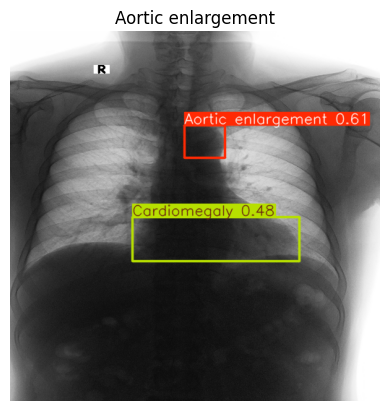

In [44]:
sample = "/kaggle/input/datasets/shubhamsalunke27/module2dataset/dataset/images/val/0108949daa13dc94634a7d650a05c0bb.png"

img, label = predict(sample)

plt.imshow(img)
plt.title(label)
plt.axis('off')

STEP 13 — Save YOLO Model

In [46]:
shutil.copy(
    "/kaggle/working/runs/detect/final_yolo/weights/best.pt",
    "/kaggle/working/best.pt"
)

'/kaggle/working/best.pt'

STEP 14 — ZIP FINAL MODELS

In [47]:
os.mkdir("/kaggle/working/final")

shutil.copy("/kaggle/working/model.pth", "/kaggle/working/final/model.pth")
shutil.copy("/kaggle/working/best.pt", "/kaggle/working/final/best.pt")

shutil.make_archive("/kaggle/working/final_models", 'zip', "/kaggle/working/final")
print("ZIP Created ")

ZIP Created 
